In [3]:
import torch as _torch
import torch.nn as _nn

# # This Upsamples to 512x512
# decoder = _nn.Sequential(
#     _nn.Conv2d(768, 512, kernel_size=3, padding=1),
#     _nn.ReLU(),
#     _nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2),
#     _nn.ReLU(),
#     _nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
#     _nn.ReLU(),
#     _nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
#     _nn.ReLU(),
#     _nn.ConvTranspose2d(64, 1, kernel_size=4, stride=4),
# )


decoder = _nn.Sequential(
    _nn.Conv2d(768, 256, kernel_size=3, padding=1),
    _nn.ReLU(),
    _nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
    _nn.ReLU(),
    _nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
    _nn.ReLU(),
    _nn.ConvTranspose2d(64, 1, kernel_size=4, stride=4),
)

x1 = _torch.randn(10, 256, 768)

x1 = x1.transpose(1, 2).reshape(-1, x1.shape[-1], 16, 16)
print(x1.shape)
x1 = decoder(x1)
print(x1.shape)

torch.Size([10, 768, 16, 16])
torch.Size([10, 1, 256, 256])


In [32]:
import torch as _torch
import torch.nn as _nn

# Upsamples to 1x256x256
embed_dim = 1024
decoder = _nn.Sequential(
    _nn.Conv2d(embed_dim, 768, kernel_size=3, padding=1),  # Output: (batch_size, 768, 8, 8)
    _nn.ReLU(),
    # _nn.ConvTranspose2d(768, 512, kernel_size=2, stride=2),  # Output: (batch_size, 512, 16, 16)
    # _nn.ReLU(),
    # _nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2),  # Output: (batch_size, 256, 32, 32)
    # _nn.ReLU(),
    # _nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),  # Output: (batch_size, 128, 64, 64)
    # _nn.ReLU(),
    # _nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),  # Output: (batch_size, 64, 128, 128)
    # _nn.ReLU(),
    # _nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # Output: (batch_size, 32, 256, 256)
    # _nn.ReLU(),
    # _nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),  # Output: (batch_size, 1, 512, 512)
)

x1 = _torch.randn(10, 64, 1024)

x1 = x1.transpose(1, 2).reshape(-1, x1.shape[-1], 8, 8)
print(x1.shape)
x1 = decoder(x1)
print(x1.shape)

torch.Size([10, 1024, 8, 8])
torch.Size([10, 768, 8, 8])


In [ ]:
import torch as _torch
import torch.nn as _nn

# Upsamples to 1x256x256
embed_dim = 1024
decoder = _nn.Sequential(
    _nn.ConvTranspose2d(embed_dim, 768, kernel_size=2, stride=2),  # Output: (batch_size, 768, 8, 8)
    _nn.ReLU(),
    _nn.ConvTranspose2d(768, 512, kernel_size=2, stride=2),  # Output: (batch_size, 512, 16, 16)
    _nn.ReLU(),
    _nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2),  # Output: (batch_size, 256, 32, 32)
    _nn.ReLU(),
    _nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),  # Output: (batch_size, 128, 64, 64)
    _nn.ReLU(),
    _nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),  # Output: (batch_size, 64, 128, 128)
    _nn.ReLU(),
    _nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # Output: (batch_size, 32, 256, 256)
    _nn.ReLU(),
    _nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),  # Output: (batch_size, 1, 512, 512)
    _nn.ReLU(),
)

x1 = _torch.randn(10, 16, 1024)

x1 = x1.transpose(1, 2).reshape(-1, x1.shape[-1], 4, 4)
print(x1.shape)
x1 = decoder(x1)
print(x1.shape)

In [5]:


patch_size = 64
output_dims = (1, 512, 512)

num_classes, H, W = output_dims
patch_embedding_dims = (10, H // patch_size * W // patch_size, 1024)
_, num_patches, embed_dim = patch_embedding_dims
resolution = int(num_patches ** 0.5)
resolution_ = resolution

num_operations = 0
while resolution_ < H:
    resolution_ *= 2
    num_operations += 1

dim = embed_dim - 128
transposed_dims = [dim]
for i in range(num_operations - 1):
    dim_ = dim - 128
    if dim_ <= 0:
        print('less')
        dim /= 2
    else:
        dim = dim_
    transposed_dims.append(dim)

print(num_operations)
print(transposed_dims)

6
[896, 768, 640, 512, 384, 256]


In [44]:
patch_size = 64
output_dims = (1, 512, 512)

num_classes, H, W = output_dims
patch_embedding_dims = (10, H // patch_size * W // patch_size, 768)
_, num_patches, embed_dim = patch_embedding_dims
resolution = int(num_patches ** 0.5)
resolution_ = resolution

num_operations = 1
while resolution_ < H:
    resolution_ *= 2
    num_operations += 1

best_factor = embed_dim // num_operations
while embed_dim % best_factor != 0:
    best_factor += 1

dim = embed_dim
transposed_dims = [dim]
for i in range(num_operations):
    dim_ = dim - best_factor
    if dim_ <= 0:
        dim //= 2
    else:
        dim = dim_
    transposed_dims.append(dim)

decoder = _nn.Sequential(
    _nn.Conv2d(embed_dim, transposed_dims[1], kernel_size=3, padding=1),
    _nn.ReLU(),
)
for i in range(1, len(transposed_dims) - 1):
    dim_1 = transposed_dims[i]
    dim_2 = transposed_dims[i + 1]
    decoder.append(
        _nn.ConvTranspose2d(dim_1, dim_2, kernel_size=2, stride=2)
    )
    decoder.append(_nn.ReLU())

decoder.append(
    _nn.ConvTranspose2d(transposed_dims[-1], 1, kernel_size=1, stride=1)
)

x1 = _torch.randn(10, num_patches, embed_dim)

x1 = x1.transpose(1, 2).reshape(-1, x1.shape[-1], resolution, resolution)
print(x1.shape)
x1 = decoder(x1)
print(x1.shape)
print(decoder)

torch.Size([10, 768, 8, 8])
torch.Size([10, 1, 512, 512])
Sequential(
  (0): Conv2d(768, 640, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): ConvTranspose2d(640, 512, kernel_size=(2, 2), stride=(2, 2))
  (3): ReLU()
  (4): ConvTranspose2d(512, 384, kernel_size=(2, 2), stride=(2, 2))
  (5): ReLU()
  (6): ConvTranspose2d(384, 256, kernel_size=(2, 2), stride=(2, 2))
  (7): ReLU()
  (8): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
  (9): ReLU()
  (10): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
  (11): ReLU()
  (12): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
  (13): ReLU()
  (14): ConvTranspose2d(32, 1, kernel_size=(1, 1), stride=(1, 1))
)


In [7]:
from src.dataset.snow import SnowDataset

snow_dataset = SnowDataset(
    dataset_dir_path='/Users/samuelthomas/Documents/University/4thYr_Final'
                     '/ECM3401_Individual_Literature_Review_and_Project/SNOW_Semantic_Segmentation'
                     '/snow_dataset',
    len_override=10000,
    resize=True,
    rotate=True,
)

image_1, mask_1 = snow_dataset[0]

import numpy as np
from PIL import Image as _Image


def print_tensor_mask(x):
    tensor = x.detach().cpu().squeeze(0).numpy()
    tensor = (tensor * 255).astype(np.uint8)
    mask_image = _Image.fromarray(tensor, mode='L')
    return mask_image


def print_tensor_image(x):
    image_np = x.detach().cpu().permute(1, 2, 0).numpy()
    image_np = (image_np * 255).astype(np.uint8)
    image = _Image.fromarray(image_np)
    return image

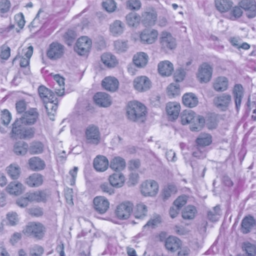

In [8]:
print_tensor_image(image_1)

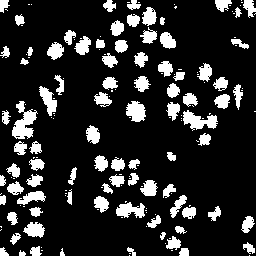

In [9]:
print_tensor_mask(mask_1)